In [2]:
GCAM_MAPPING = {
    "Africa_Eastern": ["Burundi","Comoros","Djibouti","Eritrea","Ethiopia","Kenya","Madagascar","Mauritius","Reunion","Rwanda","Sudan","Somalia","Uganda"],
    "Africa_Northern": ["Algeria","Egypt","Western Sahara","Libya","Morocco","Tunisia"],
    "Africa_Southern": ["Angola","Botswana","Lesotho","Mozambique","Malawi","Namibia","Swaziland","Tanzania","Zambia","Zimbabwe"],
    "Africa_Western": ["Benin","Burkina Faso","Central African Republic","Cote d'Ivoire","Cameroon","Democratic Republic of the Congo","Congo","Cape Verde","Gabon","Ghana","Guinea","Gambia","Guinea-Bissau","Equatorial Guinea","Liberia","Mali","Mauritania","Niger","Nigeria","Senegal","Sierra Leone","Sao Tome and Principe","Chad","Togo"],

    "Argentina": ["Argentina"],
    "Australia_NZ": ["Australia","New Zealand"],
    "Brazil": ["Brazil"],
    "Canada": ["Canada"],

    "CAC": ["Aruba","Anguilla","Netherlands Antilles","Antigua and Barbuda","Bahamas","Belize","Bermuda","Barbados","Costa Rica","Cuba","Cayman Islands","Dominica","Dominican Republic","Guadeloupe","Grenada","Guatemala","Honduras","Haiti","Jamaica","Saint Kitts and Nevis","Saint Lucia","Montserrat","Martinique","Nicaragua","Panama","El Salvador","Trinidad and Tobago","Saint Barthelemy","Sint Eustatius","Saba","Bonaire","Saint Vincent and the Grenadines"],

    "Central Asia": ["Armenia","Azerbaijan","Georgia","Kazakhstan","Kyrgyzstan","Mongolia","Tajikistan","Turkmenistan","Uzbekistan"],

    "China": ["China","Macau","Hong Kong"],
    "Colombia": ["Colombia"],

    "EU-12": ["Bulgaria","Cyprus","Czech Republic","Estonia","Hungary","Lithuania","Latvia","Malta","Poland","Romania","Slovakia","Slovenia"],
    "EU-15": ["Andorra","Austria","Belgium","Denmark","Finland","France","Germany","Greece","Greenland","Ireland","Italy","Luxembourg","Monaco","Netherlands","Portugal","Spain","Sweden","United Kingdom"],

    "Ukraine": ["Ukraine"],
    "EFTA": ["Iceland","Norway","Switzerland"],

    "Europe_Non_EU": ["Albania","Belarus","Bosnia and Herzegovina","Croatia","Kosovo","Macedonia","Moldova","Montenegro","Serbia","Turkey"],

    "India": ["India"],
    "Indonesia": ["Indonesia"],
    "Japan": ["Japan"],
    "Mexico": ["Mexico"],

    "Middle East": ["United Arab Emirates","Bahrain","Iran","Iraq","Israel","Jordan","Kuwait","Lebanon","Oman","Palestine","Qatar","Saudi Arabia","Syria","Yemen"],

    "Pakistan": ["Pakistan"],
    "Russia": ["Russia"],
    "South Africa": ["South Africa"],

    "South America_Northern": ["French Guiana","Guyana","Suriname","Venezuela"],
    "South America_Southern": ["Bolivia","Chile","Ecuador","Peru","Paraguay","Uruguay"],

    "South Asia": ["Afghanistan","Bangladesh","Bhutan","Sri Lanka","Maldives","Nepal"],

    "Southeast Asia": ["American Samoa","Brunei Darussalam","Cambodia","Kiribati","Laos","Marshall Islands","Micronesia","Myanmar","Northern Mariana Islands","Malaysia","New Caledonia","Philippines","Papua New Guinea","Solomon Islands","Singapore","Thailand","Timor-Leste","Vietnam","Vanuatu","Samoa","Fiji","Tonga","Tuvalu"],

    "South Korea": ["South Korea"],
    "Taiwan": ["Taiwan"],
    "USA": ["United States","Guam"]
}


In [ ]:
other_countries = []  

def map_to_gcam(country):
    if pd.isna(country):
        return None

    for region, countries in GCAM_MAPPING.items():
        for c in countries:
            if c.lower() in country.lower():
                return region
    other_countries.append(country)
    return "Other"

import re
import pandas as pd
import numpy as np

df = pd.read_excel("/Users/shirley/Desktop/Voluntary-Registry-Offsets-Database--v2025-12-year-end.xlsx",sheet_name="PROJECTS", header=3)

df.columns = [
    re.sub(r"\s+", "_", str(col).replace("\n", " ").replace("\r", " ").strip())
    for col in df.columns
]          

      
df["gcam_region"] = df["Country"].apply(map_to_gcam)
print(set(other_countries))  
df["total_credits_issued"] = pd.to_numeric(df["Total_Credits_Issued"], errors="coerce")
df["credit_price"] = pd.to_numeric(df["Credit_Price_(USD)"], errors="coerce")

###-----select forestry & land use projects and mapping to gcam regions, calculating weighted average price with credits issued as weights-----###

df_luc = df[df["Scope"] == "Forestry & Land Use"]
df_clean = df_luc.dropna(subset=["credit_price", "total_credits_issued", "gcam_region"])

def weighted_avg(group):
    values = group["credit_price"]
    weights = group["total_credits_issued"]
    mask = (~values.isna()) & (~weights.isna())
    values = values[mask]
    weights = weights[mask]

    if len(weights) == 0 or weights.sum() == 0:
        return values.mean() if len(values) > 0 else np.nan

    return np.average(values, weights=weights)

def weighted_se(values, weights):
    values = np.array(values)
    weights = np.array(weights)

    mask = (~np.isnan(values)) & (~np.isnan(weights))
    values = values[mask]
    weights = weights[mask]

    if len(weights) == 0 or weights.sum() == 0:
        return np.nan

    mean = np.average(values, weights=weights)

    numerator = np.sum(weights * (values - mean)**2)
    denominator = (np.sum(weights))**2

    return np.sqrt(numerator / denominator)

result = df_clean.groupby("gcam_region").apply(
    lambda g: pd.Series({
        "weighted_mean_price": weighted_avg(g),
        "weighted_se": weighted_se(
            g["credit_price"], 
            g["total_credits_issued"]
        ),
        "mean_price": g["credit_price"].mean(),
        "std_price": g["credit_price"].std(),
        "max_price": g["credit_price"].max(),
        "min_price": g["credit_price"].min(),
        "total_credits": g["total_credits_issued"].sum(),
        "n_projects": len(g)
    })
).reset_index()

result.to_excel("/Users/shirley/Desktop/forestry_credit_prices_gcam.xlsx", index=False)

print("✅ Done! 输出完成")

{'International'}
✅ Done! 输出完成


/var/folders/xt/zxpvbvsx2zb75gd2395zm9000000gn/T/ipykernel_9978/941546356.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df_clean.groupby("gcam_region").apply(


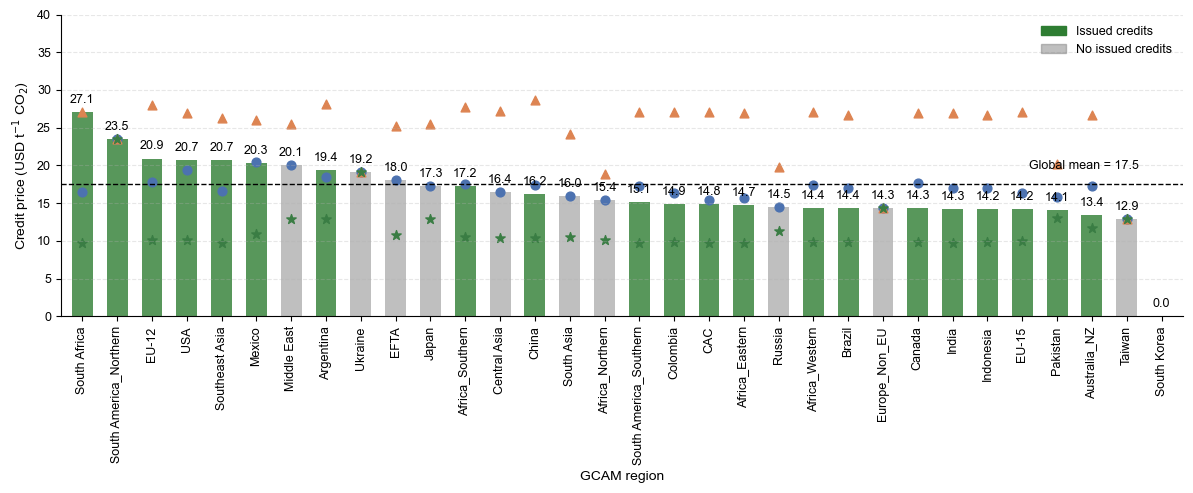

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "dejavusans",
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

df = pd.read_excel("/Users/shirley/Desktop/forestry_credit_prices_gcam2.xlsx")

df["weighted_se"] = df["weighted_se"].replace([np.inf, -np.inf], np.nan).fillna(0)

df["ci_lower"] = df["weighted_mean_price"] - 1.96 * df["weighted_se"]
df["ci_upper"] = df["weighted_mean_price"] + 1.96 * df["weighted_se"]


df = df.sort_values("weighted_mean_price", ascending=False)
yerr = np.vstack([
    df["weighted_mean_price"] - df["ci_lower"],
    df["ci_upper"] - df["weighted_mean_price"]
])
yerr = np.maximum(0, yerr)
weights = df["total_credits"].fillna(0)
weighted_mean = (
    np.average(df["weighted_mean_price"], weights=weights)
    if weights.sum() > 0
    else df["weighted_mean_price"].mean()
)


fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df))

colors = np.where(
    (df["total_credits"].isna()) | (df["total_credits"] == 0),
    "gray",
    "#2E7D32"
)
alphas = np.where(colors == "gray", 0.5, 0.8)

for i in range(len(df)):
    ax.bar(
        x[i],
        df["weighted_mean_price"].iloc[i],
        color=colors[i],
        alpha=alphas[i],
        width=0.6
    )
# ax.errorbar(
#     x,
#     df["weighted_mean_price"],
#     yerr=yerr,
#     fmt='none',
#     ecolor='black',
#     elinewidth=1.2,
#     capsize=2
# )

ax.axhline(
    weighted_mean,
    color='black',
    linestyle='--',
    linewidth=1
)
# ===== 平均值（主信息）=====
plt.scatter(
    x,
    df["mean_price"],
    marker="o",
    s=40,
    color="#4C72B0",
    label="Mean"
)

# ===== 最大值 =====
plt.scatter(
    x,
    df["max_price"],
    marker="^",
    s=40,
    color="#DD8452",
    label="Max"
)

# ===== 最小值 =====
plt.scatter(
    x,
    df["min_price"],
    marker="*",
    s=50,
    color="#3A7D44",
    label="Min"
)

ax.set_xticks(x)
ax.set_xticklabels(df["gcam_region"], rotation=90)

ax.set_ylabel("Credit price (USD t$^{-1}$ CO$_2$)")
ax.set_xlabel("GCAM region")
for i, (v, upper) in enumerate(zip(df["weighted_mean_price"], df["ci_upper"])):
    ax.text(
        i,
        upper + 0.8,
        f"{v:.1f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.text(
    len(df) * 0.85,
    weighted_mean + 2,
    f"Global mean = {weighted_mean:.1f}",
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.set_ylim(0, 40)
ax.margins(x=0.01)
legend_elements = [
    mpatches.Patch(color="#2E7D32", label="Issued credits"),
    mpatches.Patch(color="gray", alpha=0.5, label="No issued credits")
]
ax.legend(handles=legend_elements, frameon=False)

plt.tight_layout()
plt.savefig("/Users/shirley/Desktop/figure1b_forestry_credit_prices.pdf", dpi=600)

plt.show()

In [70]:

other_countries = []  

def map_to_gcam(country):
    if pd.isna(country):
        return None

    for region, countries in GCAM_MAPPING.items():
        for c in countries:
            if c.lower() in country.lower():
                return region
    other_countries.append(country)
    return "Other"

import re
import pandas as pd
import numpy as np

df = pd.read_excel("/Users/shirley/Desktop/OECD_net_carbon_price.xlsx",sheet_name="euro", header=0)
df.columns = [
    re.sub(r"\s+", "_", str(col).replace("\n", " ").replace("\r", " ").strip())
    for col in df.columns
]          
 
df["gcam_region"] = df["Reference_area"].apply(map_to_gcam)
df["total_emissions_issued"] = pd.to_numeric(df["Emission"], errors="coerce")
df["credit_price"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")*1.0824

df_clean = df.dropna(subset=["credit_price", "total_emissions_issued", "gcam_region"])

def weighted_avg(group):
    values = group["credit_price"]
    weights = group["total_emissions_issued"]
    mask = (~values.isna()) & (~weights.isna())
    values = values[mask]
    weights = weights[mask]

    if len(weights) == 0 or weights.sum() == 0:
        return values.mean() if len(values) > 0 else np.nan

    return np.average(values, weights=weights)

def weighted_se(values, weights):
    values = np.array(values)
    weights = np.array(weights)

    mask = (~np.isnan(values)) & (~np.isnan(weights))
    values = values[mask]
    weights = weights[mask]

    if len(weights) == 0 or weights.sum() == 0:
        return np.nan

    mean = np.average(values, weights=weights)

    numerator = np.sum(weights * (values - mean)**2)
    denominator = (np.sum(weights))**2

    return np.sqrt(numerator / denominator)

df2=pd.read_excel("/Users/shirley/Desktop/OECD_net_carbon_price.xlsx",sheet_name="emission", header=0)
df2 = df2[df2["Year"] == 2023]
df2["Emission"]=pd.to_numeric(df2["Emission"], errors="coerce")
df2["gcam_region"] = df2["Entity"].apply(map_to_gcam)
region_total_emissions = df2.groupby("gcam_region")["Emission"].sum()

region_total_emissions = region_total_emissions.drop("Other", errors="ignore")

result = df_clean.groupby("gcam_region").apply(
    lambda g: pd.Series({
        "weighted_mean_price": weighted_avg(g),
        "weighted_se": weighted_se(
            g["credit_price"], 
            g["total_emissions_issued"]
        ),
        "mean_price": g["credit_price"].mean(),
        "std_price": g["credit_price"].std(),
        "max_price": g["credit_price"].max(),
        "min_price": g["credit_price"].min(),
        "total_emissions": g["total_emissions_issued"].sum(),
        "n_projects": len(g),
        "region_total_emissions": region_total_emissions.get(g.name, np.nan),
        "market_proportion": (
    g["total_emissions_issued"].sum() / region_total_emissions.get(g.name, np.nan)
    if region_total_emissions.get(g.name, 0) > 0 else np.nan
)     
    })
).reset_index()

print(result[["total_emissions", "region_total_emissions", "market_proportion"]])

result.to_excel("/Users/shirley/Desktop/fossil_carbon_prices_gcam.xlsx", index=False)

# print("✅ Done! 输出完成")

    total_emissions  region_total_emissions  market_proportion
0      3.402522e+07            7.945232e+07           0.428247
1      1.183073e+07            9.138944e+07           0.129454
2      2.013565e+07            2.630494e+08           0.076547
3      1.784070e+08            1.784070e+08           1.000000
4      4.158759e+08            4.158759e+08           1.000000
5      4.839919e+08            4.839919e+08           1.000000
6      8.110819e+07            1.784331e+08           0.454558
7      5.454785e+08            5.454785e+08           1.000000
8      1.114443e+07            6.321607e+08           0.017629
9      1.217201e+10            1.996729e+10           0.609597
10     7.435472e+07            7.435472e+07           1.000000
11     5.055303e+08            5.055303e+08           1.000000
12     2.185593e+09            2.186620e+09           0.999530
13     5.054122e+08            6.516490e+08           0.775590
14     3.062756e+09            3.062756e+09           1

/var/folders/xt/zxpvbvsx2zb75gd2395zm9000000gn/T/ipykernel_27659/3904410735.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df_clean.groupby("gcam_region").apply(


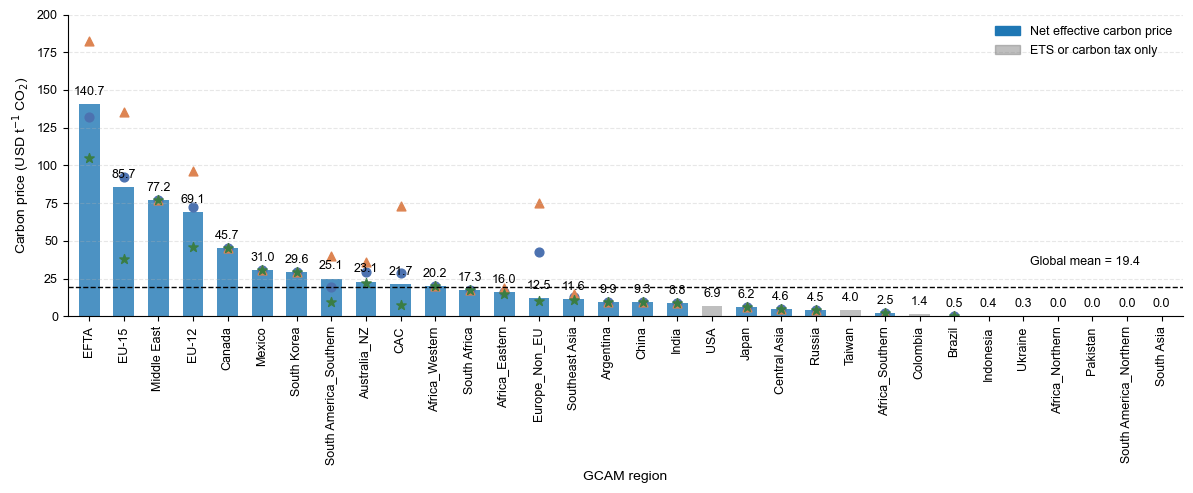

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "dejavusans",
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

df = pd.read_excel("/Users/shirley/Desktop/fossil_carbon_prices_gcam.xlsx")

df["weighted_se"] = df["weighted_se"].replace([np.inf, -np.inf], np.nan).fillna(0)

df["ci_lower"] = df["weighted_mean_price"] - 1.96 * df["weighted_se"]
df["ci_upper"] = df["weighted_mean_price"] + 1.96 * df["weighted_se"]


df = df.sort_values("weighted_mean_price", ascending=False)
yerr = np.vstack([
    df["weighted_mean_price"] - df["ci_lower"],
    df["ci_upper"] - df["weighted_mean_price"]
])
yerr = np.maximum(0, yerr)
weights = df["total_emissions"].fillna(0)
weighted_mean = (
    np.average(df["weighted_mean_price"], weights=weights)
    if weights.sum() > 0
    else df["weighted_mean_price"].mean()
)


fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df))

colors = np.where(
    (df["n_projects"].isna()) | (df["n_projects"] == 0),
    "gray",
    "#1f77b4"
)
alphas = np.where(colors == "gray", 0.5, 0.8)

for i in range(len(df)):
    ax.bar(
        x[i],
        df["weighted_mean_price"].iloc[i],
        color=colors[i],
        alpha=alphas[i],
        width=0.6
    )
# ax.errorbar(
#     x,
#     df["weighted_mean_price"],
#     yerr=yerr,
#     fmt='none',
#     ecolor='black',
#     elinewidth=1.2,
#     capsize=2
# )

ax.axhline(
    weighted_mean,
    color='black',
    linestyle='--',
    linewidth=1
)

# ===== 平均值（主信息）=====
plt.scatter(
    x,
    df["mean_price"],
    marker="o",
    s=40,
    color="#4C72B0",
    label="Mean"
)

# ===== 最大值 =====
plt.scatter(
    x,
    df["max_price"],
    marker="^",
    s=40,
    color="#DD8452",
    label="Max"
)

# ===== 最小值 =====
plt.scatter(
    x,
    df["min_price"],
    marker="*",
    s=50,
    color="#3A7D44",
    label="Min"
)
ax.set_xticks(x)
ax.set_xticklabels(df["gcam_region"], rotation=90)

ax.set_ylabel("Carbon price (USD t$^{-1}$ CO$_2$)")
ax.set_xlabel("GCAM region")
for i, (v, upper) in enumerate(zip(df["weighted_mean_price"], df["ci_upper"])):
    ax.text(
        i,
        upper + 4,
        f"{v:.1f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.text(
    len(df) * 0.85,
    weighted_mean + 15,
    f"Global mean = {weighted_mean:.1f}",
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.set_ylim(0, 200)
ax.margins(x=0.01)
legend_elements = [
    mpatches.Patch(color="#1f77b4", label="Net effective carbon price"),
    mpatches.Patch(color="gray", alpha=0.5, label="ETS or carbon tax only")
]
ax.legend(handles=legend_elements, frameon=False)

plt.tight_layout()
plt.savefig("/Users/shirley/Desktop/figure1a_fossil_carbon_prices.pdf", dpi=600)

plt.show()